In [1]:
import os
import pickle
import string
import nltk
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import accuracy_score, classification_report,confusion_matrix,ConfusionMatrixDisplay

In [2]:
os.makedirs("results", exist_ok=True)

df = pd.read_csv("/kaggle/input/datasets/nancy006/emails-dataset/emails_dataset.csv")
print(df.head())

                                                text  spam
0  Subject: naturally irresistible your corporate...     1
1  Subject: the stock trading gunslinger  fanny i...     1
2  Subject: unbelievable new homes made easy  im ...     1
3  Subject: 4 color printing special  request add...     1
4  Subject: do not have money , get software cds ...     1


In [3]:
print("\nDataset Shape:", df.shape)
print("\nClass Distribution")
print(df["spam"].value_counts())

original_text = df["text"].copy()

df["text"] = df["text"].fillna("")
df["text"] = df["text"].str.lower()

def remove_punctuation(text):
    return text.translate(
        str.maketrans("", "", string.punctuation)
    )

df["text"] = df["text"].apply(remove_punctuation)


Dataset Shape: (5728, 2)

Class Distribution
spam
0    4360
1    1368
Name: count, dtype: int64


In [4]:
print("\nOriginal Email\n")
print(original_text.iloc[0])

print("\nProcessed Email\n")
print(df["text"].iloc[0])

vectorizer = TfidfVectorizer( max_features=10000, ngram_range=(1,2),stop_words="english", lowercase=True )

X = vectorizer.fit_transform(df["text"])
y = df["spam"]


Original Email

Subject: naturally irresistible your corporate identity  lt is really hard to recollect a company : the  market is full of suqgestions and the information isoverwhelminq ; but a good  catchy logo , stylish statlonery and outstanding website  will make the task much easier .  we do not promise that havinq ordered a iogo your  company will automaticaily become a world ieader : it isguite ciear that  without good products , effective business organization and practicable aim it  will be hotat nowadays market ; but we do promise that your marketing efforts  will become much more effective . here is the list of clear  benefits : creativeness : hand - made , original logos , specially done  to reflect your distinctive company image . convenience : logo and stationery  are provided in all formats ; easy - to - use content management system letsyou  change your website content and even its structure . promptness : you  will see logo drafts within three business days . affordab

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y )

Naive Bayes Model
Accuracy : 98.17%

Classification Report

              precision    recall  f1-score   support

           0       0.98      0.99      0.99       872
           1       0.98      0.94      0.96       274

    accuracy                           0.98      1146
   macro avg       0.98      0.97      0.97      1146
weighted avg       0.98      0.98      0.98      1146



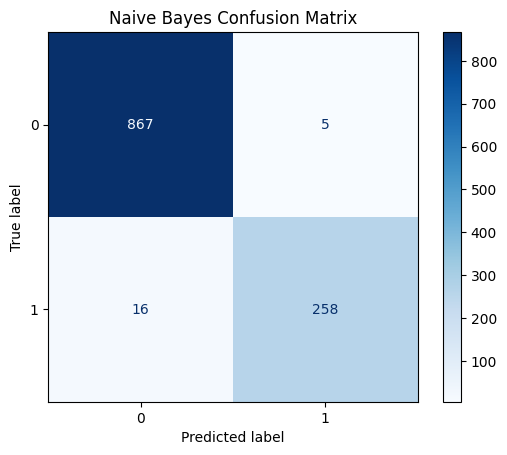

In [6]:
#naive bayes model
print("Naive Bayes Model")

nb_classifier = MultinomialNB()
nb_classifier.fit(X_train, y_train)
y_pred_nb = nb_classifier.predict(X_test)
nb_accuracy = accuracy_score(y_test, y_pred_nb)

print(f"Accuracy : {nb_accuracy*100:.2f}%")

print("\nClassification Report\n")
print(classification_report(y_test, y_pred_nb))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_nb,
    cmap="Blues"
)

plt.title("Naive Bayes Confusion Matrix")
plt.savefig("results/naive_bayes_confusion_matrix.png")
plt.show()

Logistic Rgression MODEL
Accuracy : 98.17%

Classification Report

              precision    recall  f1-score   support

           0       0.98      1.00      0.99       872
           1       0.98      0.94      0.96       274

    accuracy                           0.98      1146
   macro avg       0.98      0.97      0.97      1146
weighted avg       0.98      0.98      0.98      1146



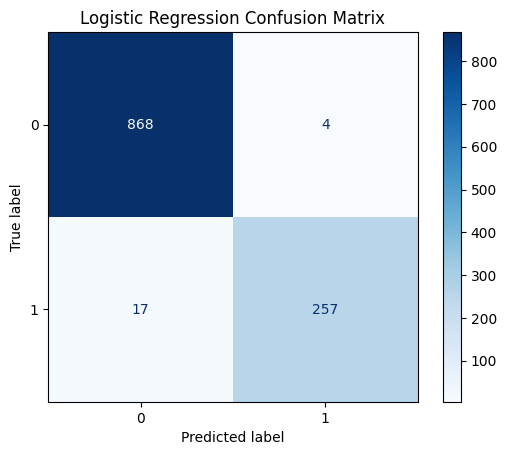

In [7]:
# Logistic regression model
print("Logistic Rgression MODEL")

lr_classifier = LogisticRegression(
    max_iter=1000,
    random_state=42
)

lr_classifier.fit(X_train,y_train)
y_pred_lr = lr_classifier.predict(X_test)
lr_accuracy = accuracy_score(y_test, y_pred_lr)

print(f"Accuracy : {lr_accuracy*100:.2f}%")
print("\nClassification Report\n")
print(classification_report( y_test, y_pred_lr))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_lr,
    cmap="Blues"
)

plt.title("Logistic Regression Confusion Matrix")
plt.savefig("results/logistic_regression_confusion_matrix.png")
plt.show()


MODEL COMPARISON
Naive Bayes Accuracy        : 98.17%
Logistic Regression Accuracy: 98.17%


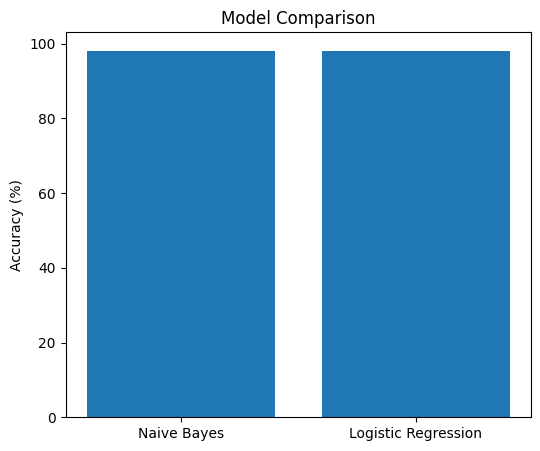

In [8]:
print("MODEL COMPARISON")
print(f"Naive Bayes Accuracy        : {nb_accuracy*100:.2f}%")
print(f"Logistic Regression Accuracy: {lr_accuracy*100:.2f}%")

plt.figure(figsize=(6,5))

models = [ "Naive Bayes", "Logistic Regression"]
accuracies = [ nb_accuracy*100, lr_accuracy*100 ]

plt.bar(models, accuracies)
plt.ylabel("Accuracy (%)")
plt.title("Model Comparison")
plt.savefig("results/model_comparison.png")
plt.show()

In [9]:
# Saving best model
if lr_accuracy > nb_accuracy:
    best_model = lr_classifier
    best_prediction = y_pred_lr
    best_name = "Logistic Regression"
else:
    best_model = nb_classifier
    best_prediction = y_pred_nb
    best_name = "Naive Bayes"

print("\nBest Model :", best_name)


Best Model : Naive Bayes


In [10]:
# saving model using PICKLE
import pickle

with open("spam_model.pkl", "wb") as file:
    pickle.dump(best_model, file)

with open("tfidf_vectorizer.pkl", "wb") as file:
    pickle.dump(vectorizer, file)

print("\nModel Saved Successfully!")


Model Saved Successfully!


In [11]:
report = classification_report( y_test, best_prediction)

with open("results/classification_report.txt", "w") as file:
    file.write(report)

with open("results/model_results.txt", "w") as file:
    file.write("EMAIL SPAM DETECTION RESULTS\n\n")
    file.write(f"Naive Bayes Accuracy : {nb_accuracy*100:.2f}%\n")
    file.write(f"Logistic Regression Accuracy : {lr_accuracy*100:.2f}%\n")
    file.write(f"Best Model : {best_name}\n")

print("Results Saved Successfully!")

Results Saved Successfully!
